In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import KernelPCA, PCA
from sklearn.metrics import classification_report, f1_score
from numpy.linalg import svd
!pip install optuna
import optuna
import warnings

warnings.filterwarnings("ignore")

загрузка и подготовка данных

In [4]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/classic-ml/abalone.csv'
df = pd.read_csv(file_path)

X = df.drop(columns=['Sex']).values
y = df['Sex'].values

# разделение на train и test ДО любых трансформаций (защита от DataLeak)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# СТАНДАРТИЗАЦИЯ (Обучаем только на train!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


аналищ спектра матриц для признаков трёх классов

--- анализ спектра матриц ---


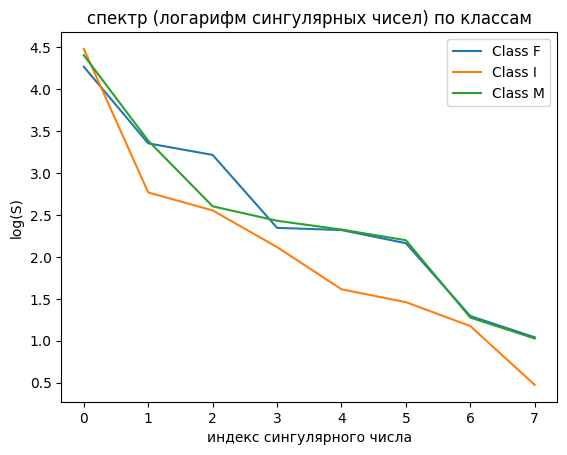

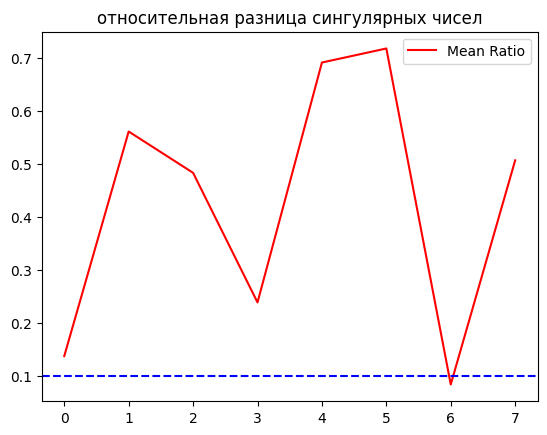

отобранные индексы признаков на основе спектра: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7)]


In [5]:
print("--- анализ спектра матриц ---")
S_dict = {}
classes = np.unique(y_train)

for cls in classes:
    # объекты конкретного класса из обучающей выборки
    X_cls = X_train_scaled[y_train == cls]
    # сингулярное разложение
    _, S, _ = svd(X_cls, full_matrices=False)
    S_dict[cls] = S
    plt.plot(np.log(S), label=f'Class {cls}')

plt.title("спектр (логарифм сингулярных чисел) по классам")
plt.xlabel("индекс сингулярного числа")
plt.ylabel("log(S)")
plt.legend()
plt.show()

# отбор признаков на основе спектра:
# ищем компоненты, где разница между сингулярными числами максимальна
ratio_MF = np.abs((S_dict['M'] - S_dict['F']) / S_dict['F'])
ratio_MI = np.abs((S_dict['M'] - S_dict['I']) / S_dict['I'])
ratio_FI = np.abs((S_dict['F'] - S_dict['I']) / S_dict['I'])

# усредненная разница (эвристика для поиска самых "различимых" компонент)
mean_ratio = (ratio_MF + ratio_MI + ratio_FI) / 3
plt.plot(mean_ratio, label='Mean Ratio', color='red')
plt.axhline(y=0.1, color='b', linestyle='--')
plt.title("относительная разница сингулярных чисел")
plt.legend()
plt.show()

# выбираем индексы признаков, где разница существенна (например, > 0.1)
selected_features = list(np.where(mean_ratio > 0.1)[0])
print(f"отобранные индексы признаков на основе спектра: {selected_features}")

KernelPCA

In [6]:
kpca = KernelPCA(kernel='rbf', gamma=0.1, n_components=X_train_scaled.shape[1])
X_train_kpca = kpca.fit_transform(X_train_scaled)
X_test_kpca = kpca.transform(X_test_scaled)

# оставляем только отобранные признаки в новом пространстве
X_train_selected = X_train_kpca[:, selected_features]
X_test_selected = X_test_kpca[:, selected_features]

настройка SVC через Optuna

In [7]:
def objective(trial):
    # 3 гиперпараметра для настройки: C, gamma, class_weight
    c_param = trial.suggest_float('C', 1e-3, 1e2, log=True)
    gamma_param = trial.suggest_float('gamma', 1e-3, 1e1, log=True)
    class_weight_param = trial.suggest_categorical('class_weight', [None, 'balanced'])

    model = SVC(kernel='rbf', C=c_param, gamma=gamma_param, class_weight=class_weight_param, random_state=42)

    # кросс-валидация на обучающей выборке
    scores = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='f1_macro')
    return scores.mean()

print("\n--- запуск Optuna для подбора гиперпараметров ---")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) # для скорости взято 30, можно увеличить до 100

print("лучшие гиперпараметры:", study.best_params)
print("лучший F-score на CV:", study.best_value)

[I 2026-05-27 09:32:22,058] A new study created in memory with name: no-name-e725f0cb-7988-41ef-92e3-b6f55e1ce93e



--- запуск Optuna для подбора гиперпараметров ---


[I 2026-05-27 09:32:23,586] Trial 0 finished with value: 0.43348873049521436 and parameters: {'C': 0.017652316620680977, 'gamma': 4.400219701077134, 'class_weight': None}. Best is trial 0 with value: 0.43348873049521436.
[I 2026-05-27 09:32:25,005] Trial 1 finished with value: 0.4304726763448998 and parameters: {'C': 0.04935442369426813, 'gamma': 0.2061121630231639, 'class_weight': None}. Best is trial 0 with value: 0.43348873049521436.
[I 2026-05-27 09:32:26,473] Trial 2 finished with value: 0.43243907422750266 and parameters: {'C': 4.839566479111322, 'gamma': 0.006833098784905222, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.43348873049521436.
[I 2026-05-27 09:32:29,244] Trial 3 finished with value: 0.4883769094780167 and parameters: {'C': 64.76023939276477, 'gamma': 0.3857143600224695, 'class_weight': None}. Best is trial 3 with value: 0.4883769094780167.
[I 2026-05-27 09:32:32,110] Trial 4 finished with value: 0.43111604315641355 and parameters: {'C': 0.43884588793894

лучшие гиперпараметры: {'C': 96.93951946580873, 'gamma': 2.5067191784810205, 'class_weight': 'balanced'}
лучший F-score на CV: 0.5352904620418983


финальная модель  и етмты

In [8]:
best_model = SVC(kernel='rbf', random_state=42, **study.best_params)
best_model.fit(X_train_selected, y_train)

y_pred_train = best_model.predict(X_train_selected)
y_pred_test = best_model.predict(X_test_selected)

print("\n--- Результаты на ТЕСТОВОЙ выборке (с отбором признаков и KernelPCA) ---")
print(classification_report(y_test, y_pred_test))


--- Результаты на ТЕСТОВОЙ выборке (с отбором признаков и KernelPCA) ---
              precision    recall  f1-score   support

           F       0.45      0.57      0.50       392
           I       0.68      0.80      0.74       403
           M       0.48      0.30      0.37       459

    accuracy                           0.54      1254
   macro avg       0.54      0.56      0.54      1254
weighted avg       0.54      0.54      0.53      1254



кривые обучения


--- построение кривых обучения (Learning Curves) ---


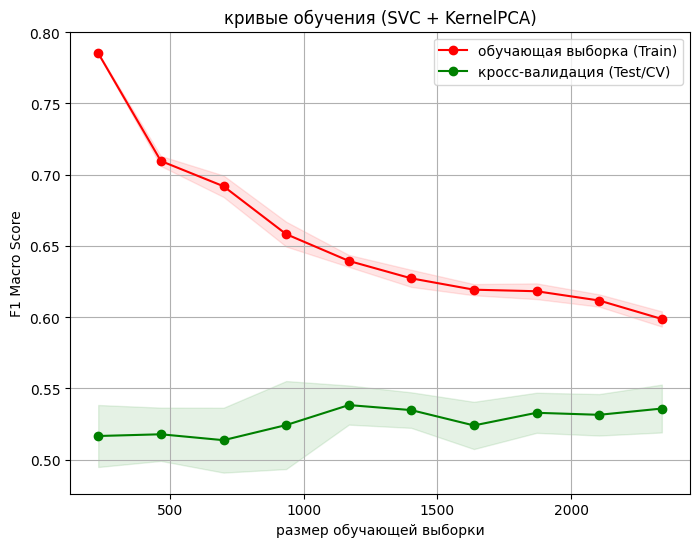

In [9]:
from sklearn.model_selection import learning_curve

print("\n--- построение кривых обучения (Learning Curves) ---")

# Вычисляем значения для кривых обучения
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train_selected,
    y_train,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# усредняем значения по фолдам кросс-валидации
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.title("кривые обучения (SVC + KernelPCA)")
plt.xlabel("размер обучающей выборки")
plt.ylabel("F1 Macro Score")

plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="обучающая выборка (Train)")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="кросс-валидация (Test/CV)")

plt.legend(loc="best")
plt.grid(True)
plt.show()